# Free-surface tank: still water and linear sloshing

Two closed-form checks of the free-surface machinery in a rectangular tank of length $L$ filled to depth $d$:

1. **Still water.** At rest the pressure is hydrostatic, $p=\rho g\,(d-y)$, and the walls carry the weight of the water.
2. **Linear standing wave.** A small cosine perturbation of the surface, $\eta(x)=a\cos(\pi x/L)$, oscillates at the natural frequency of the first sloshing mode,
   $$\omega^2 = g k\tanh(kd),\qquad k=\pi/L,$$
   (inviscid, linear: the amplitude $a\ll d$). The measured frequency tests the interplay of pressure, free surface and free-slip walls; the damping of the oscillation tests the dissipation of the scheme
   (the sloshing amplitude of a good scheme decays with the viscosity only).

The tank walls are exact analytic walls (free slip would be the physical choice; the closure used here is the solvers' default for an inviscid fluid). Choose the solver with `SCHEME`.

In [1]:
SCHEME = "delta"      # "delta" | "dfsph"
QUALITY = "quick"     # "quick" | "full"
DEVICE = "cuda:0"

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

import warpSPHBoundaries  # noqa: F401
from warpSPHBoundaries.sim.dfsph2d import domain_scene
from warpSPHBoundaries.sim.references import slosh_omega, hydrostatic
from warpSPHBoundaries.sim.solvers import make_solver, box_lattice, lattice_constants

g = 9.81
L, d, Htank, a = 1.0, 0.5, 0.8, 0.02
n = {"quick": 40, "full": 80}[QUALITY]                 # particles per unit length
T = {"quick": 2.5, "full": 3.5}[QUALITY]
dx = L / n

## Set-up
The water column is a lattice with the surface cut at $d+\eta(x)$. For `delta` the density starts on the hydrostatic profile (otherwise the first instants are an acoustic transient).

In [3]:
def build(amplitude):
    cells = (n, int(round(Htank / dx)))
    pos, hi = box_lattice(SCHEME, (0.0, 0.0), cells, dx, walls=(True, True))
    eta = amplitude * np.cos(math.pi * pos[:, 0] / hi[0])
    pos = pos[pos[:, 1] + 0.5 * dx <= d + eta + 1e-9]                # keep the cells below the perturbed surface
    h = lattice_constants(SCHEME, dx)["h"]
    scene = domain_scene("surface", (0.0, 0.0), hi, h, DEVICE)
    c0 = 10.0 * math.sqrt(g * d)
    extra = {"maxDt": 1e-3} if SCHEME == "dfsph" else {}
    sol = make_solver(SCHEME, pos, dx, scene, nu=0.0, gravity=(0.0, -g), c0=c0, device=DEVICE, **extra)
    if SCHEME == "delta":
        depth = np.clip(pos[:, 1].max() + 0.5 * dx - pos[:, 1], 0.0, None)
        sol.sim.rho = sol.sim.rho * (1.0 + g * __import__("torch").as_tensor(depth, device=DEVICE) / c0 ** 2)
    return sol, hi

## 1. Still water
Run the unperturbed tank for a short time and compare the pressure with $\rho g\,(d-y)$; the total vertical force the walls carry (pressure + the booked wall loads) is the weight of the water.

In [4]:
still, hi = build(0.0)
T0 = 0.4
still.run(T0, every=T0 / 2, report=lambda s: f"vmax {float(s.sim.v.norm(dim=1).max()):.4f}")
x, p = still.x, still.pressure
top = x[:, 1].max() + 0.5 * dx
depth = top - x[:, 1]
inner = (x[:, 0] > 0.15) & (x[:, 0] < hi[0] - 0.15) & (depth > 0.5 * dx)                    # away from the side walls and the surface layer
slope = np.polyfit(depth[inner], p[inner], 1)[0]
print(f"{SCHEME}: dp/d(depth) = {slope:.3f}  (rho g = {g:.3f}), ratio {slope / g:.4f}")
print(f"max speed after {T0} s of still water: {float(still.sim.v.norm(dim=1).max()):.4f} m/s   (c.f. sqrt(g d) = {math.sqrt(g * d):.2f})")

  t    0.201  dt 7.14e-04  vmax    0.030  vmax 0.0298  [5 s]


  t    0.401  dt 7.14e-04  vmax    0.022  vmax 0.0224  [8 s]


delta: dp/d(depth) = 9.920  (rho g = 9.810), ratio 1.0112
max speed after 0.4 s of still water: 0.0224 m/s   (c.f. sqrt(g d) = 2.21)


## 2. Standing wave

In [5]:
sol, hi = build(a)
Leff = hi[0]
deff = float(sol.volume.sum()) / Leff                       # mean depth of the perturbed column
wref = slosh_omega(Leff, deff)
print(f"scheme {SCHEME}: N = {sol.n}, L = {Leff:.4f}, mean depth {deff:.4f}; linear omega = {wref:.4f} (period {2 * math.pi / wref:.3f} s)")

ts, hl, hr, ke = [], [], [], []
def surface_height(s, side):
    x, y = s.x, s.sim.x[:, 1].detach().cpu().numpy()
    m = (x[:, 0] < 3 * dx) if side == 0 else (x[:, 0] > Leff - 3 * dx)
    return float(np.sort(y[m])[-3:].mean() + 0.5 * dx)
def record(s):
    ts.append(s.time); hl.append(surface_height(s, 0)); hr.append(surface_height(s, 1)); ke.append(0.5 * float((s.volume * (s.v ** 2).sum(1)).sum()))
sol.run(T, every=T / 5, callback=record, report=lambda s: f"h_left - d = {hl[-1] - deff:+.4f}")

scheme delta: N = 780, L = 1.0000, mean depth 0.4850; linear omega = 5.2939 (period 1.187 s)


  t    0.500  dt 7.14e-04  vmax    0.101  h_left - d = -0.0132  [21 s]


  t    1.000  dt 7.14e-04  vmax    0.135  h_left - d = +0.0120  [42 s]


  t    1.501  dt 7.14e-04  vmax    0.103  h_left - d = -0.0039  [63 s]


  t    2.000  dt 7.14e-04  vmax    0.094  h_left - d = -0.0115  [84 s]


  t    2.500  dt 7.14e-04  vmax    0.102  h_left - d = +0.0136  [104 s]


True

## Frequency and damping
The antisymmetric surface signal $h_\mathrm{left}-h_\mathrm{right}$ is $2a\cos\omega t$ for the first mode; its frequency comes from the zero crossings and a sinusoid fit.

fitted omega = 5.2840   linear omega = 5.2939   ratio 0.9981
fitted amplitude 0.0161 (initial a = 0.02, the surface height of a particle column is only resolved to ~dx/2),  fitted damping -0.035 1/s (indicative: the record is a few periods and the surface signal has a noise of order dx)


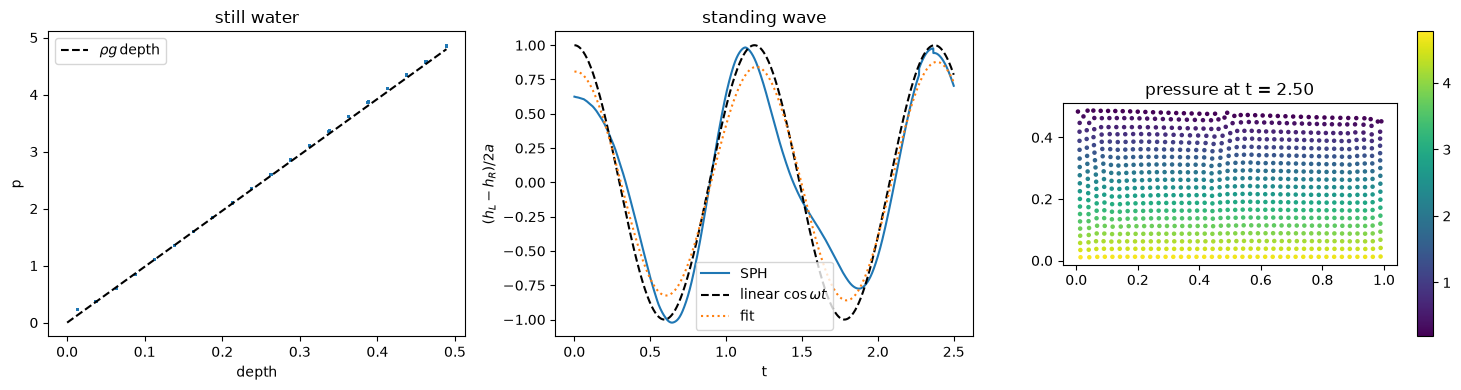

In [6]:
ts, sig = np.array(ts), (np.array(hl) - np.array(hr)) / 2
from scipy.optimize import curve_fit
model = lambda t, A, w, gam, ph: A * np.exp(-gam * t) * np.cos(w * t + ph)
popt, _ = curve_fit(model, ts, sig, p0=[a, wref, 0.1, 0.0])
A, w, gam, ph = popt
print(f"fitted omega = {w:.4f}   linear omega = {wref:.4f}   ratio {w / wref:.4f}")
print(f"fitted amplitude {abs(A):.4f} (initial a = {a}, the surface height of a particle column is only resolved to ~dx/2),  fitted damping {gam:+.3f} 1/s (indicative: the record is a few periods and the surface signal has a noise of order dx)")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(depth[inner], p[inner], ".", ms=2); dd = np.linspace(0, depth.max(), 10); ax[0].plot(dd, hydrostatic(dd, 1.0, g), "k--", label=r"$\rho g\,$depth"); ax[0].set(xlabel="depth", ylabel="p", title="still water"); ax[0].legend()
ax[1].plot(ts, sig / a, label="SPH"); ax[1].plot(ts, np.cos(wref * ts), "k--", label=r"linear $\cos\omega t$"); ax[1].plot(ts, model(ts, *popt) / a, ":", label="fit"); ax[1].set(xlabel="t", ylabel=r"$(h_L-h_R)/2a$", title="standing wave"); ax[1].legend()
q = ax[2].scatter(sol.x[:, 0], sol.x[:, 1], c=sol.pressure, s=5); ax[2].set(aspect="equal", title=f"pressure at t = {sol.time:.2f}"); plt.colorbar(q, ax=ax[2])
plt.tight_layout(); plt.show()

## What to look at

* `dp/d(depth) / rho g` is the hydrostatic check of the pressure and the free-slip wall; the residual velocity after the settling is the acoustic noise of `delta` against the quiet `dfsph`;
* the frequency ratio is the quantity to compare across schemes and resolutions. Measured at the quick resolution (n = 40): `delta` 0.998; `dfsph` 1.08 — the omniSPH-style free-surface treatment of `dfsph` (Dirichlet
  pressure at the surface, density-based solve) carries a known pressure error of about 10 % near the surface (`dp/d(depth)` ratio 1.10 here), which is what shifts the frequency; the closed / periodic
  flows of notebooks 01–05 use the converged projection instead and do not have it;
* the fitted damping is the numerical dissipation of the scheme (zero for an inviscid fluid); at this resolution and record length it is only indicative — lengthen `T` and refine to measure it.